# STEP 13. 회귀 분석 준비: 군집 테이블과 100 m 상업 영역

**목적**: 연구 개요(`SunghoSynn_ResearchOutline.docx`) 다음 단계를 위한 산출물을 만든다. 다음 단계는 각 공원 네트워크·군집의 구성 공원 주변 **100 m 상업 영역**에서 상업 POI 밀도·다양성·방문량을 재고, 회귀분석을 하는 것이다.

정의(RQ3) 4개마다:
1. **모든 공원에 군집 id 하나**
   - 최종 묶음(도보 10분 지름)에 속하면 그 묶음 id(STEP 11 GeoJSON과 같은 id)
   - 아니면 단독 군집 `{정의}-S-{park_id}`
2. **군집 속성표**
   - 규모: 공원 수, 공원 면적
   - 공간: 범위, 최대 보행거리
   - 구성: 내부 연결 밀도, 쌍별 각도 비용·보행거리
   - **큰길 속성**: NACH 상위 회랑 위 공원 비율, attachment NACH 평균
   - 고립 지수
3. **상업 영역**
   - 주 정의: 공원 가장자리에서 **보행망을 따라 100 m** 안에 있는 가로. POI는 가장 가까운 공원(네트워크 거리)의 군집에 한 번만 배정한다.
   - 민감도: 닿는 모든 공원에 중복 배정.
   - 비교용: 직선 100 m 버퍼에서 공원 부지를 뺀 영역.

정의: **D** walking distance · **N1** directional change(γ = 2) · **N2** street-axis continuity · **N3** excess field overlap

출력: `outputs/{AREA}/clusters/` (`park_cluster_membership.csv`, `clusters_{def}.csv`, `clusters_{def}.geojson`, `park_zones*.geojson`, `README.md`), `Data/derived/{AREA}/commercial_points.parquet`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 직선 100 m 버퍼 (비교용)

# 상업 영역 (주 정의): 공원 가장자리에서 보행망을 따라 100 m 이내의 가로
COMMERCIAL_DIST = 100     # 네트워크 거리 한계 (m)
FRONT_DEPTH = 50          # POI·필지를 가로에 붙이는 최대 거리 겸 영역 폴리곤 깊이 (m)
REACH_STEP = 2.5          # 가로 표본 간격 (m)
FRONT_KINDS = ["street"]  # 상점이 접하는 가로로 보는 세그먼트 종류

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
from scipy.spatial.distance import pdist
from shapely.geometry import box
import matplotlib.pyplot as plt

GJ = OUT_DIR / "geojson"
CL_DIR = OUT_DIR / "clusters"
CL_DIR.mkdir(parents=True, exist_ok=True)
DEFS = {  # 정의: (공원 레이어, 묶음 id 열, 연결선 레이어)
    "D": ("parks_D_walking_distance", "group_id", "edges_D"),
    "N1": ("parks_N1_angular_fewturn", "group_g2", "edges_N1"),
    "N2": ("parks_N2_street_axis", "group_id", "edges_N2"),
    "N3": ("parks_N3_field_overlap", "group_id", "edges_N3"),
}
parks = gpd.read_parquet(NET_DIR / "parks.parquet")
LAY = {d: gpd.read_file(GJ / f"{f}.geojson").set_index("park_id", drop=False) for d, (f, _, _) in DEFS.items()}
PIDS = LAY["N1"].index.tolist()
geom = parks.loc[PIDS].geometry
PT = geom.representative_point()
print(f"{STUDY_AREA}: {len(PIDS):,} park features")

# 공원 쌍 보행거리·각도 비용
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet", columns=["cfg", "i", "j", "D_net", "A_1600"])
pp = pp[pp.cfg == f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"]
PAIR = pp.assign(a=np.minimum(pp.i, pp.j), b=np.maximum(pp.i, pp.j)).groupby(["a", "b"])[["D_net", "A_1600"]].min()
DNET, ANG = PAIR.D_net.dropna().to_dict(), PAIR.A_1600.dropna().to_dict()
key = lambda a, b: (a, b) if a < b else (b, a)

NYC: 2,057 park features


## 13-1. 공원 단위 큰길 속성
- `on_main_5`, `on_main_10`: 공원 attachment가 NACH-1600 상위 5%·10% 회랑 stroke(각도 연속 30°)에 붙어 있는지. STEP 5에서 계산한 값이다.
- `nach_1600_mean`: 공원 attachment 세그먼트의 NACH-1600 평균. 연속값이다.

In [3]:
corr = pd.read_parquet(AREA_DIR / f"corridors_{PRIMARY}.parquet")
ps = pd.read_parquet(AREA_DIR / f"park_stroke_{PRIMARY}.parquet")
ps = ps[ps.angle == STROKE_ANGLE]
PARKATTR = pd.DataFrame(index=pd.Index(PIDS, name="park_id"))
for p_ in [0.05, 0.10]:
    sel = set(corr[(corr.angle == STROKE_ANGLE) & (corr.r == 1600) & (corr.p == p_)].stroke)
    on = ps[ps.stroke.isin(sel)].park_id.unique()
    PARKATTR[f"on_main_{int(p_ * 100)}"] = PARKATTR.index.isin(on)
cent = pd.read_parquet(AREA_DIR / f"centrality_{PRIMARY}.parquet", columns=["nach_1600"])
att = pd.read_parquet(NET_DIR / "attachments.parquet")
att = att[(att.variant == PRIMARY) & att.is_default]
PARKATTR["nach_1600_mean"] = att.join(cent, on="seg_id").groupby("park_id").nach_1600.mean().reindex(PIDS)
PARKATTR.describe(include="all").round(3)

,on_main_5,on_main_10,nach_1600_mean
count,2057,2057,2047.000
unique,2,2,NaN
top,False,False,NaN
freq,1608,1196,NaN
mean,NaN,NaN,0.977
std,NaN,NaN,0.202
min,NaN,NaN,0.000
25%,NaN,NaN,0.907
50%,NaN,NaN,1.019
75%,NaN,NaN,1.111


## 13-2. 모든 공원 → 군집 id (단독 포함)

In [4]:
memb = pd.DataFrame(index=pd.Index(PIDS, name="park_id"))
memb["name"] = parks.loc[PIDS, "name"]
memb["parent_id"] = parks.loc[PIDS, "parent_id"]
for d, (_, col, _) in DEFS.items():
    gid = LAY[d][col].reindex(PIDS)
    memb[f"{d}_cluster"] = gid.where(gid.notna(), [f"{d}-S-{p_}" for p_ in PIDS])
    memb[f"{d}_in_group"] = gid.notna()
    memb[f"{d}_status"] = LAY[d]["status"].reindex(PIDS)
memb.to_csv(CL_DIR / "park_cluster_membership.csv")
pd.DataFrame({d: {"multi-park clusters": memb.loc[memb[f"{d}_in_group"], f"{d}_cluster"].nunique(),
                  "parks in multi-park clusters": int(memb[f"{d}_in_group"].sum()),
                  "singleton clusters": int((~memb[f"{d}_in_group"]).sum()),
                  "total clusters": memb[f"{d}_cluster"].nunique()} for d in DEFS})

,D,N1,N2,N3
multi-park clusters,349,340,329,47
parks in multi-park clusters,1274,1178,1212,113
singleton clusters,783,879,845,1944
total clusters,1132,1219,1174,1991


## 13-3. 상업 영역: 공원 가장자리에서 길을 따라 100 m
직선 버퍼 대신 **보행망 거리**로 잰다.

- **출발선(거리 0)**: 공원에 붙은 가로(STEP 3 attachment, 경계 ±20 m) 가운데 공원 경계 20 m 안에 있는 구간. C 망은 가로 중심선이라 공원 앞길은 길 양쪽이 모두 거리 0이다.
- **도달 구간**: 출발선에서 보행망(모든 종류의 길)을 따라 `COMMERCIAL_DIST`(100 m) 이내인 곳.
- **상업 영역**: 도달 구간 중 가로(`FRONT_KINDS` = street). 2.5 m 간격의 **가로 표본점**으로 다룬다. 표본점 하나는 가로 길이 약 2.5 m를 대표한다.
- **가장 가까운 공원(owner)**: 표본점까지 네트워크 거리가 가장 짧은 공원. 동률이면 park_id 순.
- **POI 판정**(STEP 16): POI를 가장 가까운 가로 표본점(`FRONT_DEPTH` = 50 m 이내)에 붙인다. 그 표본점이 도달 구간이면 포함한다.

계산 순서
1. 세그먼트 끝점을 노드로 하는 primal 그래프를 만든다.
2. 공원마다 가상 출발 노드를 두고, 출발선 양 끝에서 세그먼트 끝 노드까지의 거리를 엣지로 잇는다.
3. `scipy` Dijkstra를 한계 100 m로 돌려 공원별 도달 노드와 거리를 얻는다.
4. 가로 표본점마다 공원별 거리 = min(시작 노드 경유, 끝 노드 경유, 같은 세그먼트 위 출발선까지)를 계산한다.

In [5]:
from itertools import chain
import shapely
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import Voronoi, cKDTree
from shapely.ops import substring

t0 = time.time()
segs = gpd.read_parquet(NET_DIR / f"segments_{PRIMARY}.parquet", columns=["seg_id", "kind", "geometry"]).reset_index(drop=True)
SG = segs.geometry.values
SLEN = shapely.length(SG)
nS = len(segs)
_p0, _p1 = shapely.get_point(SG, 0), shapely.get_point(SG, -1)
_node = pd.factorize(pd.Series(list(zip(np.round(shapely.get_x(_p0), 1), np.round(shapely.get_y(_p0), 1)))
                               + list(zip(np.round(shapely.get_x(_p1), 1), np.round(shapely.get_y(_p1), 1)))))[0]
N0, N1, nN = _node[:nS], _node[nS:], int(_node.max()) + 1
SIDX = pd.Series(np.arange(nS), index=segs.seg_id.values)
PARR = np.array(PIDS)
PIDX = pd.Series(np.arange(len(PIDS)), index=PIDS)
P = len(PIDS)
GEOM = geom.values
BND = shapely.boundary(GEOM)

# 1) 공원별 출발선: attachment 세그먼트 위에서 공원 경계 20 m 안에 있는 구간 [c0, c1]
D_ATT = ATTACH_BUFFER[PRIMARY]
att_all = pd.read_parquet(NET_DIR / "attachments.parquet", columns=["park_id", "seg_id", "variant", "d"])
att_all = att_all[(att_all.variant == PRIMARY) & (att_all.d == D_ATT) & att_all.park_id.isin(PIDS)].drop_duplicates(["park_id", "seg_id"])
ap, asg = PIDX.loc[att_all.park_id].values, SIDX.loc[att_all.seg_id].values
cnt = np.maximum(np.ceil(SLEN[asg] / REACH_STEP).astype(int), 1) + 1
rep = np.repeat(np.arange(len(asg)), cnt)
frac = np.concatenate([np.linspace(0, 1, c) for c in cnt])
near = shapely.distance(shapely.line_interpolate_point(SG[asg][rep], frac, normalized=True), BND[ap][rep]) <= D_ATT
span = pd.DataFrame({"pair": rep[near], "s": (frac * SLEN[asg][rep])[near]}).groupby("pair").s.agg(["min", "max"])
SRC = pd.DataFrame({"park": ap[span.index], "seg": asg[span.index], "c0": span["min"].values, "c1": span["max"].values})

# 2–3) 가상 출발 노드를 둔 그래프에서 한계 100 m Dijkstra
e = pd.DataFrame({"u": np.r_[N0, N1], "v": np.r_[N1, N0], "w": np.r_[SLEN, SLEN]})
v = pd.DataFrame({"u": nN + np.r_[SRC.park, SRC.park], "v": np.r_[N0[SRC.seg], N1[SRC.seg]],
                  "w": np.r_[SRC.c0, SLEN[SRC.seg] - SRC.c1]})
E = pd.concat([e, v]).groupby(["u", "v"], as_index=False).w.min()
G = csr_matrix((np.maximum(E.w.values, 1e-6), (E.u.values, E.v.values)), shape=(nN + P, nN + P))
rows = []
for chunk in np.array_split(np.arange(P), 40):
    D = dijkstra(G, directed=True, indices=nN + chunk, limit=COMMERCIAL_DIST)[:, :nN]
    pi, ni = np.nonzero(np.isfinite(D))
    rows.append(pd.DataFrame({"park": chunk[pi], "node": ni, "d": D[pi, ni]}))
ND = pd.concat(rows, ignore_index=True)
a = ND.merge(pd.DataFrame({"node": N0, "seg": np.arange(nS)}), on="node").rename(columns={"d": "dA"})[["park", "seg", "dA"]]
b = ND.merge(pd.DataFrame({"node": N1, "seg": np.arange(nS)}), on="node").rename(columns={"d": "dB"})[["park", "seg", "dB"]]
PSEG = a.merge(b, how="outer", on=["park", "seg"]).merge(SRC, how="outer", on=["park", "seg"])
print(f"{len(att_all):,} attachment pairs → {len(SRC):,} with a source span; parks with a source: {SRC.park.nunique():,}/{P:,}; "
      f"(park, segment) pairs within {COMMERCIAL_DIST} m: {len(PSEG):,}  ({time.time() - t0:.0f}s)")

33,500 attachment pairs → 33,488 with a source span; parks with a source: 2,047/2,057; (park, segment) pairs within 100 m: 119,279  (11s)


In [6]:
# 4) 가로 표본점: 공원 근처 가로 세그먼트를 2.5 m 간격으로 (점 = 구간 중심, 가중치 = 구간 길이)
IS_FRONT = segs.kind.isin(FRONT_KINDS).values
reach_far = COMMERCIAL_DIST + 2 * FRONT_DEPTH + D_ATT + 20
cs = np.unique(segs.sindex.query(shapely.buffer(GEOM, reach_far), predicate="intersects")[1])
cs = cs[IS_FRONT[cs]]
m = np.maximum(np.ceil(SLEN[cs] / REACH_STEP).astype(int), 1)
first = np.r_[0, np.cumsum(m)[:-1]]
PT_SEG = np.repeat(cs, m)
PT_W = np.repeat(SLEN[cs] / m, m)
PT_S = (np.arange(m.sum()) - np.repeat(first, m) + 0.5) * PT_W
FIRST, COUNT = pd.Series(first, index=cs), pd.Series(m, index=cs)

# 공원별 거리: 도달한 (공원, 가로 세그먼트) 쌍마다 그 세그먼트의 표본점 전부에 대해
pr = PSEG[PSEG.seg.isin(cs)]
f, c = FIRST.loc[pr.seg].values, COUNT.loc[pr.seg].values
ridx = np.repeat(np.arange(len(pr)), c)
pid = np.repeat(f, c) + (np.arange(c.sum()) - np.repeat(np.cumsum(c) - c, c))
s, L = PT_S[pid], SLEN[PT_SEG[pid]]
d = np.minimum(pr.dA.fillna(np.inf).values[ridx] + s, pr.dB.fillna(np.inf).values[ridx] + (L - s))
hasc = pr.c0.notna().values[ridx]
dc = np.maximum(np.maximum(pr.c0.fillna(0).values[ridx] - s, s - pr.c1.fillna(0).values[ridx]), 0)
d = np.where(hasc, np.minimum(d, dc), d)
keep = d <= COMMERCIAL_DIST
MEMB = pd.DataFrame({"park": pr.park.values[ridx][keep], "pt": pid[keep], "d": d[keep]})
MEMB["park_id"] = PARR[MEMB.park.values]
own = MEMB.sort_values(["pt", "d", "park_id"]).drop_duplicates("pt")
n_reach = MEMB.groupby("pt").size()

# 표본점 집합: 도달한 점 + 그 100 m 안의 도달하지 않은 가로 점 (POI가 '진짜 가장 가까운 가로'에 붙도록)
reached = np.zeros(len(PT_SEG), bool)
reached[own.pt.values] = True
xy_all = shapely.get_coordinates(shapely.line_interpolate_point(SG[PT_SEG], PT_S))
dn, _ = cKDTree(xy_all[reached]).query(xy_all, k=1, distance_upper_bound=2 * FRONT_DEPTH)
keep_pt = np.isfinite(dn)
new_id = np.full(len(PT_SEG), -1)
new_id[keep_pt] = np.arange(keep_pt.sum())
POINTS = pd.DataFrame({"seg": PT_SEG[keep_pt], "s": PT_S[keep_pt], "w": PT_W[keep_pt],
                       "x": xy_all[keep_pt, 0], "y": xy_all[keep_pt, 1], "reached": reached[keep_pt]})
POINTS["owner"] = -1
POINTS["d_owner"] = np.nan
POINTS["n_parks"] = 0
POINTS.loc[new_id[own.pt.values], "owner"] = own.park.values
POINTS.loc[new_id[own.pt.values], "d_owner"] = own.d.values
POINTS.loc[new_id[n_reach.index.values], "n_parks"] = n_reach.values
MEMB["pt"] = new_id[MEMB.pt.values]
XY = POINTS[["x", "y"]].values
W = POINTS.w.values
OWNER = POINTS.owner.values

# 공원별 가로 길이: 배타(가장 가까운 공원) / 비배타(닿는 모든 공원)
LEN_X = pd.Series(np.bincount(OWNER[OWNER >= 0], weights=W[OWNER >= 0], minlength=P), index=PIDS)
LEN_O = pd.Series(np.bincount(MEMB.park.values, weights=W[MEMB.pt.values], minlength=P), index=PIDS)
uniq_len = W[POINTS.reached.values].sum()
assert np.isclose(LEN_X.sum(), uniq_len), "배타 길이의 합 = 도달 가로의 고유 길이"
assert LEN_O.sum() >= uniq_len - 1e-6
chk = MEMB.groupby("pt").d.min()
assert np.allclose(POINTS.d_owner.values[chk.index.values], chk.values), "owner의 거리 = 닿는 공원 중 최소"
NO_REACH = LEN_X.index[LEN_O.values == 0].tolist()
print(f"street sample points: {len(POINTS):,} ({POINTS.reached.sum():,} reached)  ({time.time() - t0:.0f}s)")
print(f"street within {COMMERCIAL_DIST} m by network: {uniq_len / 1000:,.0f} km unique; sum over parks {LEN_O.sum() / 1000:,.0f} km "
      f"→ {1 - uniq_len / LEN_O.sum():.0%} of park-street reach is shared with another park")
print(f"per park: median {LEN_O.median():.0f} m reached, {LEN_X.median():.0f} m after nearest-park assignment; "
      f"parks with no street within {COMMERCIAL_DIST} m: {len(NO_REACH)} ({(~pd.Index(PIDS).isin(att_all.park_id)).sum()} have no attachment)")

street sample points: 1,532,439 (740,644 reached)  (16s)
street within 100 m by network: 1,789 km unique; sum over parks 2,178 km → 18% of park-street reach is shared with another park
per park: median 877 m reached, 726 m after nearest-park assignment; parks with no street within 100 m: 31 (10 have no attachment)


## 13-3b. 영역 폴리곤
POI 판정 규칙과 같은 영역을 폴리곤으로 만든다. 면적·인구·일자리·용도지역 집계와 지도에 쓴다.
- 가로 표본점의 Voronoi 칸 = 그 점이 '가장 가까운 가로 지점'인 곳.
- **배타 영역**(주 규칙): owner가 그 공원인 점들의 칸을 합치고, 그 공원의 도달 가로에서 `FRONT_DEPTH`(50 m) 안으로 자른 뒤 공원 부지를 뺀다.
- **비배타 영역**(중복 허용): 그 공원이 닿는 모든 점의 칸으로 같은 방식.
- 공원 부지는 **NYC Parks 전체 폴리곤**(Flagship·대형 공원 포함)을 뺀다.

In [7]:
def voronoi_cells(xy, want):
    """xy 전체로 Voronoi를 만들고, want(불리언)인 점의 칸만 폴리곤으로 돌려준다. 좌표가 같은 점은 같은 칸을 쓴다."""
    u, inv = np.unique(xy.round(2), axis=0, return_inverse=True)
    inv = inv.ravel()
    b = [u[:, 0].min() - 5000, u[:, 1].min() - 5000, u[:, 0].max() + 5000, u[:, 1].max() + 5000]
    vor = Voronoi(np.vstack([u, [[b[0], b[1]], [b[0], b[3]], [b[2], b[1]], [b[2], b[3]]]]))
    need = np.unique(inv[want])
    regs = [vor.regions[r] for r in vor.point_region[need]]
    lens = np.fromiter(map(len, regs), int, len(regs))
    flat = np.fromiter(chain.from_iterable(regs), int, lens.sum())
    assert lens.min() >= 3 and flat.min() >= 0, "모든 칸이 유한해야 함"
    poly = shapely.make_valid(shapely.polygons(shapely.linearrings(vor.vertices[flat], indices=np.repeat(np.arange(len(regs)), lens))))
    pos = np.full(len(u), -1)
    pos[need] = np.arange(len(need))
    return poly, pos[inv]          # 칸 배열, 점 → 칸 위치(-1 = 요청하지 않음)


def run_lines(pt, park):
    """(공원, 표본점) 목록 → 공원별 가로 선(연속한 표본점 구간을 세그먼트에서 잘라 낸 것)"""
    o = np.lexsort((pt, park))
    pt, park = pt[o], park[o]
    seg = POINTS.seg.values[pt]
    brk = np.r_[True, (park[1:] != park[:-1]) | (seg[1:] != seg[:-1]) | (pt[1:] != pt[:-1] + 1)]
    st, en = np.where(brk)[0], np.r_[np.where(brk)[0][1:], len(pt)] - 1
    s0 = POINTS.s.values[pt[st]] - W[pt[st]] / 2
    s1 = POINTS.s.values[pt[en]] + W[pt[en]] / 2
    lines = np.array([substring(SG[sg], max(lo, 0.0), min(hi, SLEN[sg])) for sg, lo, hi in zip(seg[st], s0, s1)], dtype=object)
    lines = np.where(shapely.get_type_id(lines) == 1, lines, None)           # 길이 0인 조각은 버림
    g = gpd.GeoSeries(lines, crs=CRS).groupby(park[st]).agg(lambda x: shapely.union_all(x.dropna().values))
    return g.reindex(range(P))


def only_polygons(g):
    if g.geom_type in ("Polygon", "MultiPolygon"):
        return g
    parts = [x for x in shapely.get_parts(g) if x.geom_type in ("Polygon", "MultiPolygon")]
    return shapely.union_all(parts) if parts else shapely.Polygon()


def minus_parks(g):
    """공원 부지(NYC Parks 전체)를 뺀다"""
    if g.is_empty:
        return shapely.Polygon()
    hit = ALL_PARKS_TREE.query(g, predicate="intersects")
    if len(hit):
        g = g.difference(shapely.union_all(ALL_PARKS[hit]))
    return only_polygons(g if g.is_valid else shapely.make_valid(g))


def zones(pt, park, cells, cellpos):
    lines = run_lines(pt, park)
    cg = gpd.GeoDataFrame({"park": park}, geometry=cells[cellpos[pt]], crs=CRS).dissolve("park").geometry.reindex(range(P))
    z = []
    for k in range(P):
        if lines.iloc[k] is None or cg.iloc[k] is None:
            z.append(shapely.Polygon())
            continue
        z.append(minus_parks(cg.iloc[k].intersection(lines.iloc[k].buffer(FRONT_DEPTH))))
    return gpd.GeoSeries(z, index=PIDS, crs=CRS), gpd.GeoSeries(lines.values, index=PIDS, crs=CRS)


t0 = time.time()
ALL_PARKS = gpd.read_file(PARKS_PATH).to_crs(CRS).geometry.make_valid().values
ALL_PARKS_TREE = shapely.STRtree(ALL_PARKS)
CELLS, CELLPOS = voronoi_cells(XY, POINTS.reached.values)
print(f"Voronoi cells for {len(CELLS):,} reached points  ({time.time() - t0:.0f}s)")
rp = np.where(OWNER >= 0)[0]
ZONE_X, LINE_X = zones(rp, OWNER[rp], CELLS, CELLPOS)                           # 배타 (주 규칙)
ZONE_O, LINE_O = zones(MEMB.pt.values, MEMB.park.values, CELLS, CELLPOS)         # 비배타 (중복 허용)
print(f"zones built  ({time.time() - t0:.0f}s): exclusive {ZONE_X.area.sum() / 1e6:.1f} km², "
      f"non-exclusive sum {ZONE_O.area.sum() / 1e6:.1f} km²")

Voronoi cells for 740,644 reached points  (23s)


zones built  (137s): exclusive 80.8 km², non-exclusive sum 95.7 km²


### 비교용: 직선 100 m 버퍼
기존 정의(공원 100 m 버퍼 − 공원 부지)는 비교용으로 남긴다. 버퍼도 "가장 가까운 공원"(직선 거리) 기준으로 겹치지 않게 나눈다. 공원 경계에 5 m 간격으로 점을 찍어 Voronoi로 나누는 방식이다.

In [8]:
park_buf = geom.buffer(COMMERCIAL_BUFFER)


def cluster_ring(members):
    return minus_parks(park_buf.loc[members].union_all())


bp, bo = [], []
for k, bd in enumerate(BND):
    for part in shapely.get_parts(bd):
        nb = max(int(shapely.length(part) // 5), 8)
        bp.append(shapely.get_coordinates(shapely.line_interpolate_point(part, np.linspace(0, 1, nb, endpoint=False), normalized=True)))
        bo.append(np.full(nb, k))
bp, bo = np.vstack(bp), np.concatenate(bo)
bp, ui = np.unique(bp.round(2), axis=0, return_index=True)
bo = bo[ui]
bcells, bpos = voronoi_cells(bp, np.ones(len(bp), bool))
bz = gpd.GeoDataFrame({"park": bo}, geometry=shapely.intersection(bcells[bpos], park_buf.values[bo]), crs=CRS).dissolve("park").geometry
BUF_X = gpd.GeoSeries([minus_parks(g) if g is not None else shapely.Polygon() for g in bz.reindex(range(P)).values], index=PIDS, crs=CRS)
RING = gpd.GeoSeries([minus_parks(g) for g in park_buf.values], index=PIDS, crs=CRS)
ring_union_area = shapely.union_all(RING.values).area
assert np.isclose(BUF_X.area.sum(), ring_union_area, rtol=1e-3), "버퍼 배타 영역의 합 = 버퍼 합집합"
# 버퍼 안 가로 길이 (공원에서 직선 100 m 이내의 가로)
qi, qj = segs.sindex.query(park_buf.values, predicate="intersects")
fr = IS_FRONT[qj]
LEN_BUF = pd.Series(np.bincount(qi[fr], weights=shapely.length(shapely.intersection(SG[qj[fr]], park_buf.values[qi[fr]])), minlength=P), index=PIDS)
cmp = pd.DataFrame({"network 100 m (reached)": LEN_O, "network 100 m (nearest park)": LEN_X, "straight 100 m buffer": LEN_BUF})
print(f"buffer: union {ring_union_area / 1e6:.1f} km², sum of overlapping rings {RING.area.sum() / 1e6:.1f} km²")
print("street length per park (m):")
cmp.describe().loc[["mean", "25%", "50%", "75%"]].round(0)

buffer: union 118.1 km², sum of overlapping rings 144.8 km²
street length per park (m):


,network 100 m (reached),network 100 m (nearest park),straight 100 m buffer
mean,1059.0,870.0,1286.0
25%,610.0,410.0,793.0
50%,877.0,726.0,1052.0
75%,1220.0,1069.0,1441.0


### 점검: 폴리곤과 POI 판정 규칙이 같은 영역인가
배타 영역 안에 임의 점을 찍고, 판정 규칙(가장 가까운 가로 표본점 → owner)으로 배정한 공원이 그 점을 담은 폴리곤의 공원과 같은지 본다.

In [9]:
rng = np.random.default_rng(0)
zb = ZONE_X[~ZONE_X.is_empty]
bb = zb.total_bounds
cand_xy = np.c_[rng.uniform(bb[0], bb[2], 1_500_000), rng.uniform(bb[1], bb[3], 1_500_000)]
ti, zi = shapely.STRtree(zb.values).query(shapely.points(cand_xy), predicate="intersects")
test_xy, test_zone = cand_xy[ti], PIDX.loc[zb.index[zi]].values
dd, nn = cKDTree(XY).query(test_xy, k=1, distance_upper_bound=FRONT_DEPTH + REACH_STEP)
got = np.where(np.isfinite(dd), OWNER[np.minimum(nn, len(XY) - 1)], -1)
agree = (got == test_zone).mean()
print(f"{len(test_xy):,} random points inside exclusive zones: rule assigns the same park in {agree:.2%}")
assert agree >= 0.99

58,153 random points inside exclusive zones: rule assigns the same park in 99.99%


In [10]:
# 저장: 표본점, 공원별 소속, 공원 단위 레이어
pts_out = POINTS.assign(seg_id=segs.seg_id.values[POINTS.seg.values],
                        owner=np.where(OWNER >= 0, PARR[np.maximum(OWNER, 0)], None)).drop(columns="seg")
pts_out.index.name = "point_id"
pts_out.to_parquet(AREA_DIR / "commercial_points.parquet")
MEMB[["park_id", "pt", "d"]].rename(columns={"pt": "point_id"}).to_parquet(AREA_DIR / "commercial_membership.parquet", index=False)
PZ = gpd.GeoDataFrame({"park_id": PIDS, "name": parks.loc[PIDS, "name"].values,
                       "street_len_m": LEN_X.round(1).values, "zone_area_m2": ZONE_X.area.round(1).values,
                       "street_len_reached_m": LEN_O.round(1).values, "zone_area_reached_m2": ZONE_O.area.round(1).values,
                       "buffer_street_len_m": LEN_BUF.round(1).values, "buffer_zone_area_m2": BUF_X.area.round(1).values,
                       "has_attachment": pd.Index(PIDS).isin(att_all.park_id), "no_street_reach": LEN_O.values == 0},
                      geometry=ZONE_X.values, crs=CRS)
def write_geojson(gdf, path, tol=1.0):
    """공유용 GeoJSON: 1 m 단순화, 좌표 소수 6자리. 계산에는 Data/derived의 정밀한 도형을 쓴다."""
    out = gdf.copy()
    out["geometry"] = [only_polygons(shapely.make_valid(g)) if g.geom_type.endswith("Polygon") else g
                       for g in shapely.simplify(out.geometry.values, tol, preserve_topology=True)]
    out.to_crs(4326).to_file(path, driver="GeoJSON", COORDINATE_PRECISION=6)


# 정밀한 도형 (계산용, GeoParquet)
PZ.to_parquet(AREA_DIR / "park_zones.parquet")
PZ.set_geometry(ZONE_O.values).to_parquet(AREA_DIR / "park_zones_overlap.parquet")
PZ.set_geometry(BUF_X.values).to_parquet(AREA_DIR / "park_zones_buffer.parquet")
# 공유용 GeoJSON
write_geojson(PZ, CL_DIR / "park_zones.geojson")
write_geojson(PZ.set_geometry(ZONE_O.values), CL_DIR / "park_zones_overlap.geojson")
write_geojson(PZ.set_geometry(BUF_X.values), CL_DIR / "park_zones_buffer.geojson")
has_line = np.array([g is not None and not g.is_empty for g in LINE_X.values])
write_geojson(gpd.GeoDataFrame(PZ[["park_id", "name", "street_len_m"]].copy(), geometry=LINE_X.values, crs=CRS)[has_line],
              CL_DIR / "park_streets.geojson")
print(f"parks with no street within {COMMERCIAL_DIST} m by network: {len(NO_REACH)}")
parks.loc[NO_REACH, ["name", "typecategory", "borough", "acres"]].head(30)

parks with no street within 100 m by network: 31


,name,typecategory,borough,acres
park_id,,,,
B165A,Spring Creek Park,Nature Area,B,2.203
B394,Four Sparrow Marsh,Nature Area,B,64.665
M039#1,Harlem River Park (1/15),Parkway,M,46.657
M039#10,Harlem River Park (10/15),Parkway,M,46.657
M039#11,Harlem River Park (11/15),Parkway,M,46.657
M039#12,Harlem River Park (12/15),Parkway,M,46.657
M039#14,Harlem River Park (14/15),Parkway,M,46.657
M039#4,Harlem River Park (4/15),Parkway,M,46.657
M039#5,Harlem River Park (5/15),Parkway,M,46.657


## 13-4. 군집 속성표 + 영역 레이어
- `clusters_{def}.geojson`: 군집의 **네트워크 상업 영역**(구성 공원 배타 영역의 합집합). 주 분석 단위다.
- `clusters_{def}_buffer.geojson`: 직선 버퍼 영역(비교용).
- `shared_street_share`: 군집이 닿는 가로 중 다른 군집의 공원도 닿는 비율. 배정 규칙이 얼마나 영향을 주는지 보여 준다.

In [11]:
def cluster_table(d):
    _, col, efile = DEFS[d]
    e = gpd.read_file(GJ / f"{efile}.geojson", ignore_geometry=True)
    robust = set(zip(e.loc[e.share >= 0.5, "park_i"], e.loc[e.share >= 0.5, "park_j"]))
    lay = LAY[d]
    # 중복 허용 규칙의 군집별 가로 길이와, 다른 군집도 닿는 비율
    cl_of = memb[f"{d}_cluster"].reindex(PIDS).values
    mc = pd.DataFrame({"cl": cl_of[MEMB.park.values], "pt": MEMB.pt.values}).drop_duplicates()
    mc["w"] = W[mc.pt.values]
    mc["shared"] = mc.pt.map(mc.groupby("pt").size()).values > 1
    len_o = mc.groupby("cl").w.sum()
    len_sh = mc[mc.shared].groupby("cl").w.sum()
    rows = []
    for cid, members in memb.groupby(f"{d}_cluster").groups.items():
        m = sorted(members)
        n = len(m)
        pairs = [(a, b) for k, a in enumerate(m) for b in m[k + 1:]]
        walks = [DNET.get(key(a, b), np.inf) for a, b in pairs]
        angs = [ANG.get(key(a, b), np.nan) for a, b in pairs]
        n_int = sum(key(a, b) in robust for a, b in pairs)
        types = parks.loc[m, "typecategory"]
        lo = float(len_o.get(cid, 0.0))
        rows.append({
            "definition": d, "cluster_id": cid, "n_parks": n, "is_singleton": n == 1,
            "park_ids": ";".join(m), "park_names": "; ".join(parks.loc[m, "name"].astype(str)),
            "boroughs": "/".join(sorted(parks.loc[m, "borough"].unique())),
            "park_area_acres": round(float(parks.loc[m, "piece_acres"].sum()), 3),
            "dominant_type": types.mode().iloc[0], "n_types": types.nunique(),
            "extent_km": round(pdist(np.c_[PT[m].x, PT[m].y]).max() / 1000, 3) if n > 1 else 0.0,
            "max_walk_m": round(max(walks), 1) if n > 1 else 0.0,
            "median_walk_m": round(float(np.median(walks)), 1) if n > 1 else np.nan,
            "internal_robust_links": n_int,
            "link_density": round(n_int / len(pairs), 3) if n > 1 else np.nan,
            "median_angle_deg": round(float(np.nanmedian(angs)), 1) if n > 1 and np.isfinite(angs).any() else np.nan,
            "share_on_main_5": round(float(PARKATTR.loc[m, "on_main_5"].mean()), 3),
            "share_on_main_10": round(float(PARKATTR.loc[m, "on_main_10"].mean()), 3),
            "nach_1600_mean": round(float(PARKATTR.loc[m, "nach_1600_mean"].mean()), 4),
            "isolation_persistence_mean": round(float(lay.loc[m, "isolation_persistence"].mean()), 3),
            "street_len_m": round(float(LEN_X.loc[m].sum()), 1),
            "street_len_reached_m": round(lo, 1),
            "shared_street_share": round(float(len_sh.get(cid, 0.0)) / lo, 3) if lo > 0 else np.nan,
            "n_no_street_reach": int((LEN_O.loc[m] == 0).sum()),
            "buffer_zone_area_m2": round(float(BUF_X.loc[m].area.sum()), 1),
            "buffer_ring_area_m2": round(cluster_ring(m).area, 1),
            "geometry": only_polygons(shapely.union_all(ZONE_X.loc[m].values)),
            "_buf": only_polygons(shapely.union_all(BUF_X.loc[m].values)),
        })
    t = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
    t["zone_area_m2"] = t.area.round(1)
    return t


TABLES = {}
for d in DEFS:
    t = cluster_table(d)
    buf = gpd.GeoDataFrame(t[["definition", "cluster_id", "n_parks", "is_singleton", "buffer_zone_area_m2", "buffer_ring_area_m2"]],
                           geometry=t["_buf"].values, crs=CRS)
    t = t.drop(columns="_buf")
    TABLES[d] = t
    t.drop(columns="geometry").to_csv(CL_DIR / f"clusters_{d}.csv", index=False)
    write_geojson(t, CL_DIR / f"clusters_{d}.geojson")
    write_geojson(buf, CL_DIR / f"clusters_{d}_buffer.geojson")
    print(d, len(t), "clusters")
summary = pd.DataFrame({d: {
    "clusters": len(t), "multi-park": int((~t.is_singleton).sum()), "singletons": int(t.is_singleton.sum()),
    "median parks (multi)": t.loc[~t.is_singleton, "n_parks"].median(),
    "median max walk m (multi)": t.loc[~t.is_singleton, "max_walk_m"].median(),
    "median street length m": round(t.street_len_m.median()),
    "median street length m (multi)": round(t.loc[~t.is_singleton, "street_len_m"].median()),
    "median zone area ha": round(t.zone_area_m2.median() / 1e4, 2),
    "mean shared street share": round(t.shared_street_share.mean(), 3),
    "clusters with no street reach": int((t.street_len_reached_m == 0).sum()),
    "median buffer zone area ha": round(t.buffer_zone_area_m2.median() / 1e4, 2),
    "multi-park clusters touching a top-5% main street": round(float((t.loc[~t.is_singleton, "share_on_main_5"] > 0).mean()), 3),
} for d, t in TABLES.items()})
summary.to_csv(CL_DIR / "cluster_summary.csv")
summary

D 1132 clusters


N1 1219 clusters


N2 1174 clusters


N3 1991 clusters


,D,N1,N2,N3
clusters,1132.000,1219.000,1174.000,1991.000
multi-park,349.000,340.000,329.000,47.000
singletons,783.000,879.000,845.000,1944.000
median parks (multi),3.000,3.000,3.000,2.000
median max walk m (multi),197.700,391.400,336.300,413.600
median street length m,1061.000,986.000,997.000,746.000
median street length m (multi),2430.000,2540.000,2776.000,678.000
median zone area ha,4.970,4.620,4.690,3.520
mean shared street share,0.057,0.195,0.166,0.330
clusters with no street reach,25.000,31.000,30.000,30.000


## 13-5. 검증

In [12]:
for d, t in TABLES.items():
    ids = [p_ for s_ in t.park_ids for p_ in s_.split(";")]
    assert len(ids) == len(set(ids)) == len(PIDS), d                      # 공원-군집 1:1
    assert t.geometry.is_valid.all(), d
    assert (t.loc[~t.is_singleton, "max_walk_m"] <= WALK_LIMIT + 1e-6).all(), d
    n_groups = LAY[d][DEFS[d][1]].dropna().nunique()
    assert (~t.is_singleton).sum() == n_groups, d                        # 군집 수 = 묶음 수 + 단독 수
    assert np.isclose(t.street_len_m.sum(), uniq_len, rtol=1e-3), d                 # 배타 규칙: 군집 길이의 합 = 도달 가로의 고유 길이
    assert (t.street_len_reached_m >= t.street_len_m - 0.5).all(), d
print("✓ every park is in exactly one cluster per definition; zones valid; walking diameter ≤ 800 m; "
      "exclusive street length adds up to the unique reached length")

✓ every park is in exactly one cluster per definition; zones valid; walking diameter ≤ 800 m; exclusive street length adds up to the unique reached length


## 13-6. 미리보기: 같은 지역의 정의별 군집 상업 영역
굵은 선 = 군집에 배정된 가로(가장 가까운 공원 규칙), 옅은 면 = 영역 폴리곤.

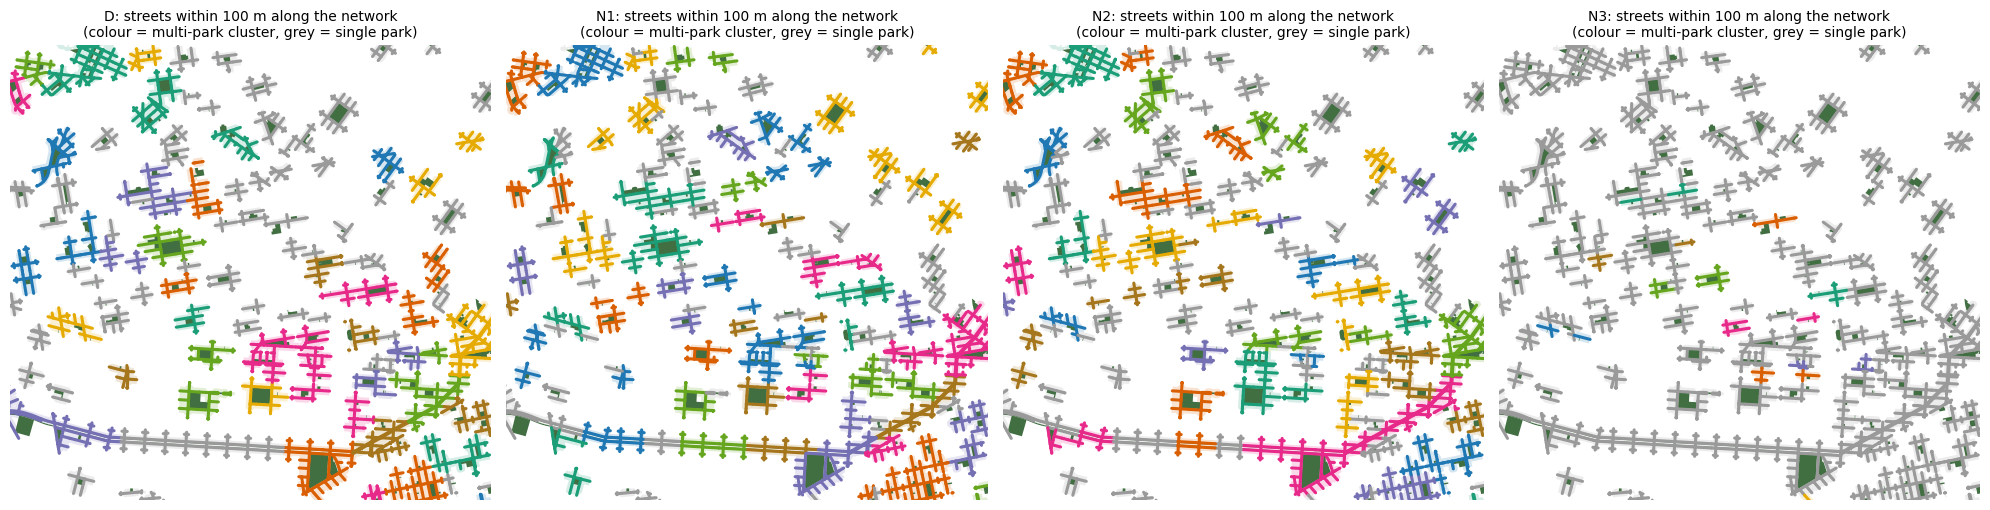

In [13]:
win = gpd.GeoSeries([box(-73.968, 40.664, -73.904, 40.710)], crs=4326).to_crs(CRS).iloc[0]
pal = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D", "#1F78B4"]
in_win = pd.Series(geom.intersects(win).values | np.array([g is not None and g.intersects(win) for g in LINE_X.values]), index=PIDS)
fig, axes = plt.subplots(1, 4, figsize=(20, 5.6))
for ax, (d, t) in zip(axes, TABLES.items()):
    sub = t[t.intersects(win)].reset_index(drop=True)
    colour = {cid: (pal[k % len(pal)] if not single else "#9A9A9A") for k, (cid, single) in enumerate(zip(sub.cluster_id, sub.is_singleton))}
    sub[~sub.is_empty].plot(ax=ax, color=[colour[c] for c in sub.cluster_id[~sub.is_empty]], alpha=0.18, edgecolor="none")
    ln = gpd.GeoDataFrame({"cl": memb.loc[in_win[in_win].index, f"{d}_cluster"].values},
                          geometry=LINE_X.loc[in_win[in_win].index].values, crs=CRS)
    ln = ln[ln.geometry.notna() & ~ln.is_empty & ln.cl.isin(colour)]
    ln.plot(ax=ax, color=[colour[c] for c in ln.cl], lw=2.2, capstyle="round")
    parks.loc[PIDS][in_win.values].plot(ax=ax, color="#2C5F2D", alpha=0.9)
    ax.set_xlim(win.bounds[0], win.bounds[2]); ax.set_ylim(win.bounds[1], win.bounds[3]); ax.set_axis_off()
    ax.set_title(f"{d}: streets within {COMMERCIAL_DIST} m along the network\n(colour = multi-park cluster, grey = single park)", fontsize=10)
plt.tight_layout()
fig.savefig(CL_DIR / "preview_rings_B.png", dpi=160)
plt.show()

## 13-7. 데이터 사전 (README.md)

In [14]:
readme = f"""# Park clusters and commercial areas ({STUDY_AREA})

Generated by `14_step13_cluster_table.ipynb` for the next stage of the research outline (commercial activity around park networks).

## Definitions (RQ3)
| key | network definition |
|---|---|
| D | walking distance: shortest walking distance ≤ d (d ∈ {{200, 400, 800}} m) — proximity baseline |
| N1 | directional change: simplest route between the parks turns ≤ θ (few turns), Louvain γ = 2 |
| N2 | street-axis continuity: both parks on the same continuous street axis (angular-continuity stroke) |
| N3 | excess few-turn field overlap |

All multi-park clusters satisfy: every pair of parks within a 10-minute walk ({WALK_LIMIT} m). Parks not in a robust group are **singleton clusters** (`<def>-S-<park_id>`), so every park belongs to exactly one cluster per definition.

## Commercial area (main definition): within {COMMERCIAL_DIST} m of the park edge along the walking network
- Distance 0 = the parts of the streets attached to the park (STEP 3) that lie within {D_ATT:.0f} m of the park boundary. The network is street centrelines, so both sides of a fronting street are at distance 0.
- The area = street-type segments reachable within {COMMERCIAL_DIST} m along the network, handled as sample points every {REACH_STEP} m.
- **POI rule**: snap the POI to the nearest street sample point (≤ {FRONT_DEPTH} m). It counts if that point is reached. POIs inside park land are excluded.
- **Main assignment (`nearest`)**: the park with the shortest network distance to that point (ties: park id order). Each POI counts once.
- **Sensitivity (`overlap`)**: every park that reaches the point; within a cluster a POI counts once.
- Zone polygons = the Voronoi cells of the reached sample points, cut to {FRONT_DEPTH} m from the reached streets, minus all NYC park land. They cover the same area as the POI rule and are used for area, population, jobs and zoning.
- Comparison (`buffer`): the earlier straight-line {COMMERCIAL_BUFFER} m buffer minus park land, split between parks by nearest park (straight line).

## Files
- `park_cluster_membership.csv` — one row per park feature: cluster id, in_group flag and status for each definition
- `clusters_<def>.csv` — one row per cluster (attributes below)
- `clusters_<def>.geojson` — same rows; geometry = network commercial zone of the cluster, `nearest` rule (EPSG:4326)
- `clusters_<def>_buffer.geojson` — straight-line buffer zone of the cluster (comparison)
- `park_zones.geojson` — per park: network zone, `nearest` rule
- `park_zones_overlap.geojson` — per park: everything the park reaches (zones of different parks overlap)
- `park_zones_buffer.geojson` — per park: straight-line buffer zone, split by nearest park
- `park_streets.geojson` — per park: the street lines assigned to it (`nearest` rule)
- `cluster_summary.csv`, `preview_rings_B.png`
- GeoJSON geometries are simplified by 1 m for sharing. Exact geometries for computation: `Data/derived/{STUDY_AREA}/park_zones.parquet`, `park_zones_overlap.parquet`, `park_zones_buffer.parquet`
- Sample points and park–point distances: `Data/derived/{STUDY_AREA}/commercial_points.parquet`, `commercial_membership.parquet`

## Cluster fields
| field | meaning |
|---|---|
| n_parks, is_singleton, park_ids, park_names, boroughs | membership |
| park_area_acres | park supply inside the cluster (sum of member feature areas) |
| dominant_type, n_types | NYC Parks typecategory mix |
| extent_km | largest straight-line distance between member parks |
| max_walk_m, median_walk_m | largest / median shortest walking distance between member parks (max ≤ 800 m) |
| internal_robust_links, link_density | member pairs linked in ≥ 50% of the definition's settings, and share of all member pairs |
| median_angle_deg | median minimum angular cost (simplest path ≤ 1.6 km) between member parks |
| share_on_main_5 / share_on_main_10 | share of member parks attached to a top-5% / top-10% NACH-1600 street axis (“main street” attribute) |
| nach_1600_mean | mean NACH-1600 of member parks' attachment segments |
| isolation_persistence_mean | mean share of settings in which members have no link |
| street_len_m | street length assigned to the cluster (`nearest` rule) — main density denominator |
| zone_area_m2 | area of the cluster's network zone (`nearest` rule) |
| street_len_reached_m | street length reached by any member park (`overlap` rule) |
| shared_street_share | share of the reached street length that parks of another cluster also reach |
| n_no_street_reach | member parks with no street within {COMMERCIAL_DIST} m along the network |
| buffer_zone_area_m2 / buffer_ring_area_m2 | straight-line buffer: area after nearest-park split / area of the overlapping ring |

## Park zone fields
| field | meaning |
|---|---|
| street_len_m, zone_area_m2 | `nearest` rule |
| street_len_reached_m, zone_area_reached_m2 | `overlap` rule (everything the park reaches) |
| buffer_street_len_m, buffer_zone_area_m2 | straight-line buffer (comparison) |
| has_attachment | park is attached to the walking network (STEP 3) |
| no_street_reach | no street-type segment within {COMMERCIAL_DIST} m along the network |
"""
(CL_DIR / "README.md").write_text(readme)
print(sorted(p_.name for p_ in CL_DIR.iterdir()))

['README.md', 'cluster_summary.csv', 'clusters_D.csv', 'clusters_D.geojson', 'clusters_D_buffer.geojson', 'clusters_N1.csv', 'clusters_N1.geojson', 'clusters_N1_buffer.geojson', 'clusters_N2.csv', 'clusters_N2.geojson', 'clusters_N2_buffer.geojson', 'clusters_N3.csv', 'clusters_N3.geojson', 'clusters_N3_buffer.geojson', 'park_cluster_membership.csv', 'park_streets.geojson', 'park_zones.geojson', 'park_zones_buffer.geojson', 'park_zones_overlap.geojson', 'preview_rings_B.png']
